#### __Для работы в colab__

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# import os

In [ ]:
# os.chdir("/content/drive/MyDrive/YP-sprint2-project-text_autocomplete_malgepav")

In [ ]:
# %pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.5 MB/s eta 0:00:00


In [ ]:
# %pip install rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=e2cd6b67c7c6ca80f789929ba194364dcc3d14c4ee4b03c5ac7b44874da2069f
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


 ### __Загрузка и обработка tweets.txt__

In [ ]:
from src.data_utils import download_tweets, clean_tweets, partition_into_train_test

In [ ]:
#Загрузка tweets.txt:
url = "https://code.s3.yandex.net/deep-learning/tweets.txt"
save_path = "data/tweets.txt"
download_tweets(url, save_path)

In [ ]:
#создание cleaned_tweets_csv:
frac = 0.3 #около 500_000 твитов
clean_tweets(frac)

In [ ]:
#разбиение на Train-val-test
partition_into_train_test()

/content/drive/MyDrive/YP-sprint2-project-text_autocomplete_malgepav/src/data_utils.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tweets_df["begining"] = tweets_df["tokens"].apply(
/content/drive/MyDrive/YP-sprint2-project-text_autocomplete_malgepav/src/data_utils.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tweets_df["ending"] = tweets_df["tokens"].apply(
/content/drive/MyDrive/YP-sprint2-project-text_autocomplete_malgepav/src/data_utils.py:67: SettingWithCopyWarning: 
A value is trying to b

### __Создание тренировочого и валидационного датасетов__

In [ ]:
from transformers import AutoTokenizer

In [ ]:
from src.next_token_dataset import create_next_token_dataset_from_csv
from src.seq_generation_dataset import create_seq_gen_dataset_from_csv

In [ ]:
tokenizer_model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(tokenizer_model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
train_dataset = create_next_token_dataset_from_csv("data/train_tweets.csv", tokenizer)

In [ ]:
val_dataset = create_seq_gen_dataset_from_csv("data/val_tweets.csv")

### __Создание тренировочного и валидационного даталоудеров__

In [ ]:
import torch
from src.next_token_dataset import get_next_token_collate_fn
from src.seq_generation_dataset import seq_gen_collate_fn
from torch.utils.data import DataLoader

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
device

'cuda'

In [ ]:
train_loader = DataLoader(train_dataset,
                          batch_size=32,
                          collate_fn=get_next_token_collate_fn(tokenizer),
                         shuffle=True)

In [ ]:
val_loader = DataLoader(val_dataset,
                          batch_size=512,
                          collate_fn=seq_gen_collate_fn,
                         shuffle=False)

### __Создание модели__

In [ ]:
from src.lstm_model import TextAutoCompleteLSTM

In [ ]:
input_dim  = 256
hidden_dim = 128
dropout = 0.1
bidirecttional = True
num_layers = 2

In [ ]:
model = TextAutoCompleteLSTM(input_dim=input_dim,
                             hidden_dim=hidden_dim,
                             dropout=dropout,
                             tokenizer=tokenizer,
                             num_layers=num_layers,
                             bidirectional=bidirecttional,
                            device = device).to(device)


### __Тренировка модели__

In [ ]:
import torch.nn as nn
import torch.optim as optim
from src.lstm_train import train_epoch
from src.eval_lstm import model_eval_metrics

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 1e-3)
num_epochs = 10

In [ ]:
train_losses = []
rouge1 = []
rouge2 = []

In [ ]:
for epoch in range(1, num_epochs+1):
    print(f"Epoch {epoch}: training")
    epoch_loss = train_epoch(model=model,
                train_loader=train_loader,
                loss_fn=loss_fn, optimizer=optimizer,
                epoch=epoch,
                device=device)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch}: validation")
    rouge1_epoch, rouge2_epoch = model_eval_metrics(model=model,
                                                    loader=val_loader,
                                                      tokenizer=tokenizer,
                                                        device=device)
    rouge1.append(rouge1_epoch)
    rouge2.append(rouge2_epoch)
    print(f"Epoch {epoch}: loss = {epoch_loss:.4f}, rouge1 = {rouge1_epoch:.4f}, rouge2 = {rouge2_epoch:.4f}")

    checkpoint = {
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'losses': train_losses,
    'rogue1': rouge1,
    'rogue2': rouge2
    }
    torch.save(checkpoint, f'models/checkpoint_epoch{epoch}.pth')


Epoch 1: training


Epoch 1:: 100%|██████████| 11927/11927 [11:28<00:00, 17.32it/s]


Epoch 1: validation


100%|██████████| 88/88 [03:29<00:00,  2.39s/it]


Epoch 1: loss = 4.7227, rouge1 = 0.0436, rouge2 = 0.0033
Epoch 2: training


...

Epoch 9: loss = 4.0335, rouge1 = 0.0446, rouge2 = 0.0035
Epoch 10: training


Epoch 10:: 100%|██████████| 11927/11927 [11:27<00:00, 17.36it/s]


Epoch 10: validation


100%|██████████| 88/88 [03:30<00:00,  2.39s/it]


Epoch 10: loss = 4.0174, rouge1 = 0.0430, rouge2 = 0.0035


### __Отображение метрик__

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.style.use("ggplot")

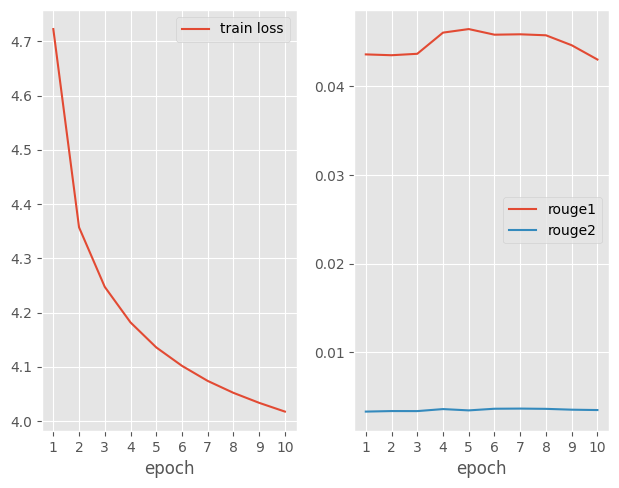

In [ ]:
fig, (ax1, ax2) = plt.subplots(1,2)
plt.tight_layout()
ax1.plot(list(range(1,num_epochs+1)),train_losses, label="train loss")
ax1.set_xticks(list(range(1,num_epochs+1)))
ax1.set_xlabel("epoch")
ax1.legend()
ax1.grid(True)

ax2.plot(list(range(1,num_epochs+1)),rouge1, label="rouge1")
ax2.plot(list(range(1,num_epochs+1)),rouge2, label="rouge2")
ax2.set_xticks(list(range(1,num_epochs+1)))
ax2.set_xlabel("epoch")
ax2.legend()
ax2.grid(True)

plt.show()

Видим,что наблюдается стабильное снижение loss на тренировочных данных, значение метрики rouge1 растет до 5-й эпохи, а потом снижается, возможно можно говорить о переобучении, метрика rouge 2 практически не изменяется.

---



#### __Примеры автодополнения__

используем веса после 5-й эпохи, на которой достигалось максимальное значение rouge1

In [ ]:
if device == "cuda":
    checkpoint = torch.load("models/checkpoint_epoch5.pth",
                         weights_only=False)
else:
    checkpoint = torch.load("models/checkpoint_epoch5.pth",
                            map_location=torch.device('cpu'),
                            weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [ ]:
from random import randint

In [ ]:
for i in range(7):
    index = randint(0,len(val_dataset)-1)
    begining, ending = val_dataset.__getitem__(index)
    begining_tokenized  = tokenizer(begining, return_tensors="pt")
    generated_ending = model.generate(max_new_tokens=len(ending.split()),
                                      **begining_tokenized)
    decoded = tokenizer.decode(generated_ending[0], skip_special_tokens=True)
    print(f"Example {i+1}:")
    print("Begining: |"+begining)
    print("Original: |"+begining+'|'+ending)
    print("Generated: |"+decoded)
    print('-'*30)

Example 1:
Begining: |i'm more tired then i should be, eyes r worn out- nite time 4 me hope you all out in the
Original: |i'm more tired then i should be, eyes r worn out- nite time 4 me hope you all out in the|twitterverse sleep well. and yep no movies today
Generated: |i ' m more tired then i should be, eyes r worn out - nite time 4 me hope you all out in the
------------------------------
Example 2:
Begining: |my wireless is being silly &gt;&lt;
Original: |my wireless is being silly &gt;&lt;|grrrh ! -----
Generated: |my wireless is being silly & gt ; & lt ; & lt ;
------------------------------
Example 3:
Begining: |i painted the dogs nails hot pink-the boyf is
Original: |i painted the dogs nails hot pink-the boyf is|less than pleased
Generated: |i painted the dogs nails hot pink - the boyf is to me.
------------------------------
Example 4:
Begining: |afternoon twitterbugs! just woke uo and i think i pulled a
Original: |afternoon twitterbugs! just woke uo and i think i pulled a|mus

### __Предобученный трансформер__

In [ ]:
from transformers import AutoModelForCausalLM

model_name = "distilgpt2"

gpt2_tokenizer = AutoTokenizer.from_pretrained(model_name)
gpt2_model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [36]:
r1, r2 = model_eval_metrics(model = gpt2_model,
                            loader=val_loader,
                            tokenizer=gpt2_tokenizer,
                            device=device
                            )


100%|██████████| 88/88 [14:13<00:00,  9.69s/it]


In [37]:
print("Показатели rouge1 и rouge2 для трансформера на валидационном датасете:")
print(f"Rouge1: {r1:.4f}, Rouge2: {r2:.4f}")


Показатели rouge1 и rouge2 для трансформера на валидационном датасете:
Rouge1: 0.0587, Rouge2: 0.0052


#### __Примеры дополнения одних и тех же предложений трансформером и lstm моделью__

In [ ]:
for i in range(5):
        index = randint(0,len(val_dataset)-1)
        begining, ending = val_dataset.__getitem__(index)
        begining_tokenized  = gpt2_tokenizer(begining, return_tensors="pt").to(device)
        generated_ending = gpt2_model.generate(**begining_tokenized,
                                               pad_token_id=gpt2_tokenizer.eos_token_id,
                                               max_new_tokens=max(1,len(ending.split())))
        decoded = gpt2_tokenizer.decode(generated_ending[0], skip_special_tokens=True)

        begining_tokenized_lstm  = tokenizer(begining, return_tensors="pt")
        generated_ending_lstm = model.generate(max_new_tokens=len(ending.split()),
                                      **begining_tokenized_lstm)
        decoded_lstm = tokenizer.decode(generated_ending_lstm[0], skip_special_tokens=True)


        print(f"Example {i+1}:")
        print("Begining: |"+begining)
        print("Original: |"+begining+'|'+ending)
        print("Generated gpt2: |"+decoded)
        print("Generated lstm: |"+decoded_lstm)
        print('-'*30)

Example 1:
Begining: |cry, i missed the massive moshpit
Original: |cry, i missed the massive moshpit|on this morning
Generated gpt2: |cry, i missed the massive moshpit.


Generated lstm: |cry, i missed the massive moshpit.
------------------------------
Example 2:
Begining: |how should i save a relationship where there is
Original: |how should i save a relationship where there is|no future for it
Generated gpt2: |how should i save a relationship where there is no relationship between the
Generated lstm: |how should i save a relationship where there is to be?
------------------------------
Example 3:
Begining: |i'm not ready to go to
Original: |i'm not ready to go to|school yet.
Generated gpt2: |i'm not ready to go to the next
Generated lstm: |i ' m not ready to go to to the
------------------------------
Example 4:
Begining: |you know what? i think for now we did
Original: |you know what? i think for now we did|*hi-fives* go us
Generated gpt2: |you know what? i think for now we did it.

Видим, что метрики качества rogue1 и rogue2 предобученного трансформера выше, чем у построенной lstm модели: rouge1 выше примерно на 25%, а rouge2 примерно на 50%, хотя и для той и для той модели показатели кажутся низкими.

По примерам генерации можно сказать, трансформер в большинстве случаев дает более осмысленные окончания, хотя и не может угадать оригинал.

#### __Замерим качество работы трансформера на тестовом датасете__

In [ ]:
test_dataset = create_seq_gen_dataset_from_csv("data/test_tweets.csv")

In [ ]:
test_loader = DataLoader(test_dataset,
                          batch_size=512,
                          collate_fn=seq_gen_collate_fn,
                         shuffle=False)

In [ ]:
r1_test, r2_test = model_eval_metrics(model = gpt2_model,
                            loader=test_loader,
                            tokenizer=gpt2_tokenizer,
                            device=device
                            )

100%|██████████| 88/88 [13:52<00:00,  9.45s/it]


In [34]:
print("Показатели rouge1 и rouge2 для трансформера на валидационном датасете:")
print(f"Rouge1: {r1_test:.4f}, Rouge2: {r2_test:.4f}")

Transformer rouge scores on test dataset:
Rouge1: 0.0575, Rouge2: 0.0052
